In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
#Use sklearn's California Housing dataset
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# Statistical summary
print("Statistical Summary:")
df.describe()

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Fill any missing values with median of the column
df.fillna(df.median(), inplace=True)

print("\nMissing values after cleaning:", df.isnull().sum().sum())

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Missing values after cleaning: 0


In [ ]:
# Remove extreme outliers in the target column
# Outliers can hurt model performance

Q1 = df['MedHouseVal'].quantile(0.25)
Q3 = df['MedHouseVal'].quantile(0.75)
IQR = Q3 - Q1

# Keep only rows within 1.5 * IQR range
df = df[(df['MedHouseVal'] >= Q1 - 1.5 * IQR) &
        (df['MedHouseVal'] <= Q3 + 1.5 * IQR)]

print("Dataset shape after removing outliers:", df.shape)

Dataset shape after removing outliers: (19569, 9)


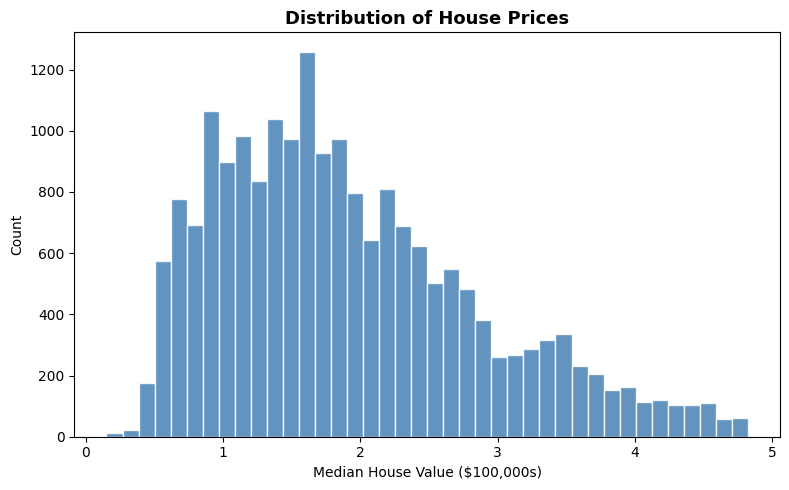

In [ ]:
# ---- House Price Distribution ----

plt.figure(figsize=(8, 5))
plt.hist(df['MedHouseVal'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Distribution of House Prices', fontsize=13, fontweight='bold')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

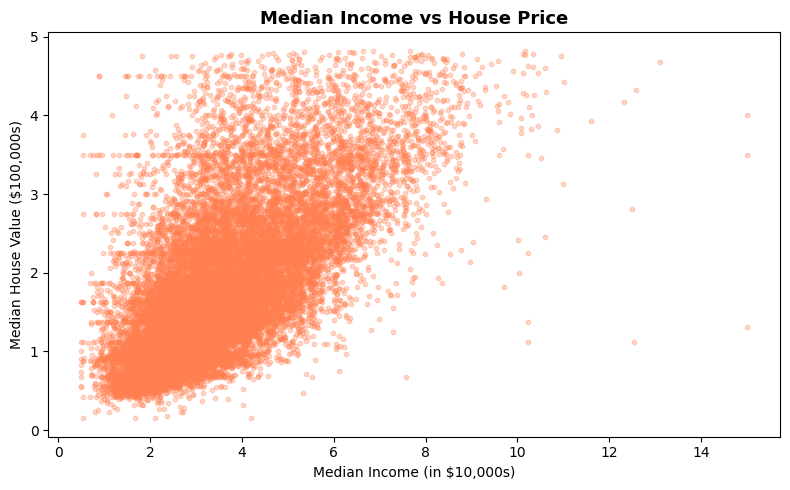

In [ ]:
# ---- Income vs Price Scatter Plot ----

plt.figure(figsize=(8, 5))
plt.scatter(df['MedInc'], df['MedHouseVal'], alpha=0.3, color='coral', s=10)
plt.title('Median Income vs House Price', fontsize=13, fontweight='bold')
plt.xlabel('Median Income (in $10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.tight_layout()
plt.show()


In [ ]:
# Separate features (X) and target (y)
X = df.drop('MedHouseVal', axis=1)   # all columns except price
y = df['MedHouseVal']                 # only the price column

print("Features:", X.columns.tolist())
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Features shape: (19569, 8)
Target shape: (19569,)


In [ ]:
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 15655
Testing samples:  3914


In [ ]:
# Feature Scaling: normalize all features to same scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling complete!")

Scaling complete!


In [ ]:
# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## Step 8: Evaluate the Model

In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results:")
print(f"  MAE  (Mean Absolute Error): {mae:.4f}")
print(f"  RMSE (Root Mean Sq Error):  {rmse:.4f}")
print(f"  R²   (Accuracy of fit):     {r2:.4f}")
print()

Model Evaluation Results:
  MAE  (Mean Absolute Error): 0.4594
  RMSE (Root Mean Sq Error):  0.6073
  R²   (Accuracy of fit):     0.6013



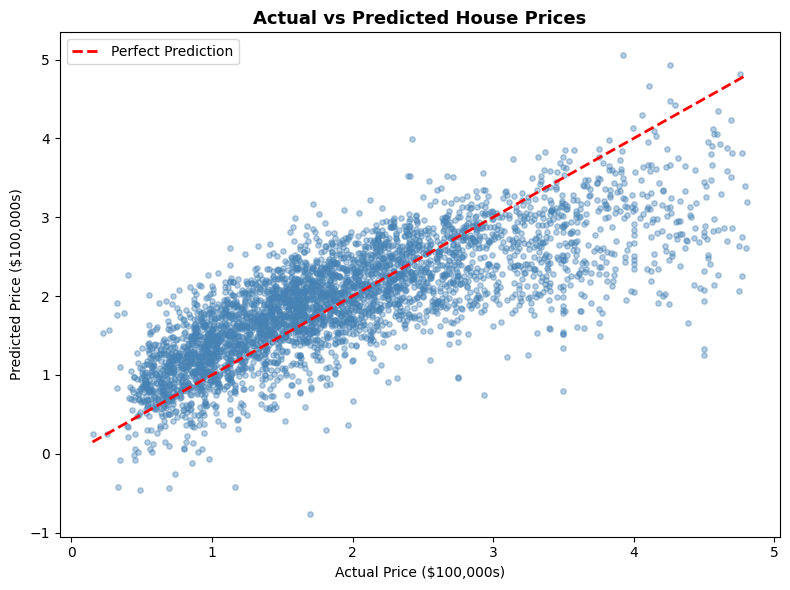

In [ ]:
# ---- Actual vs Predicted Plot ----

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted House Prices', fontsize=13, fontweight='bold')
plt.xlabel('Actual Price ($100,000s)')
plt.ylabel('Predicted Price ($100,000s)')
plt.legend()
plt.tight_layout()
plt.show()

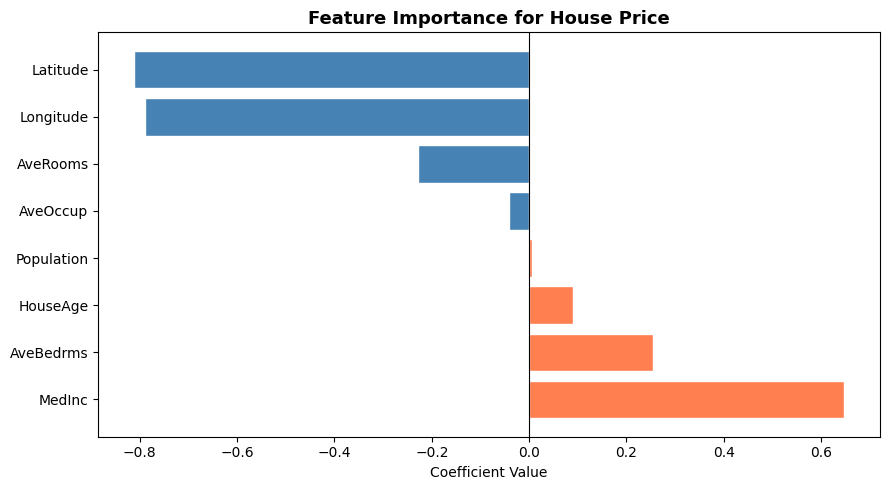

   Feature  Coefficient
    MedInc     0.647831
 AveBedrms     0.254275
  HouseAge     0.090247
Population     0.006025
  AveOccup    -0.041194
  AveRooms    -0.228762
 Longitude    -0.789243
  Latitude    -0.812106


In [ ]:
# Get feature coefficients
feature_names = df.drop('MedHouseVal', axis=1).columns
coefficients = model.coef_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(9, 5))
colors = ['coral' if c > 0 else 'steelblue' for c in importance_df['Coefficient']]
plt.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors, edgecolor='white')
plt.title('Feature Importance for House Price', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(importance_df.to_string(index=False))